## 1. Import Libraries

In [3]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.svm import SVC
from transformers import AutoModel, AutoTokenizer

try:
    import torch_directml
    if torch_directml.is_available():
        device = torch_directml.device()
    else:
        device = torch.device('cpu')
except ImportError:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: privateuseone:0


## 2. Load and Clean the Dataset

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    tokens = text.split()
    return ' '.join(tokens)

df = pd.read_csv('dataset/Truth_Seeker_Model_Dataset.csv')
df = df[['tweet', 'BinaryNumTarget']].dropna()
df['BinaryNumTarget'] = df['BinaryNumTarget'].astype(int)
df['clean_tweet'] = df['tweet'].astype(str).apply(clean_text)
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

print('Dataset shape:', df.shape)
print(df[['tweet', 'clean_tweet', 'BinaryNumTarget']].head())
print('Class distribution:')
print(df['BinaryNumTarget'].value_counts())

Dataset shape: (10000, 3)
                                               tweet  \
0  @fattycattie @robquinnpc @SammyTMcCarty @WCCO ...   
1  never forget, Matt Santos ran on Medicare for ...   
2  @BilldeBlasio You are mandating an experimenta...   
3  @SenSanders The working class is literally bei...   
4  @PeterTong9 @timand2037 @ClimateAudit But none...   

                                         clean_tweet  BinaryNumTarget  
0  fattycattie robquinnpc sammytmccarty wcco the ...                0  
1  never forget matt santos ran on medicare for a...                1  
2  billdeblasio you are mandating an experimental...                0  
3  sensanders the working class is literally bein...                1  
4  petertong9 timand2037 climateaudit but none of...                1  
Class distribution:
BinaryNumTarget
1    5181
0    4819
Name: count, dtype: int64


## 3. Extract BERT Embeddings

In [5]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()

def encode_texts(texts, batch_size=32):
    all_embeddings = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        inputs = {key: value.to(device) for key, value in inputs.items()}
        with torch.no_grad():
            outputs = bert_model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].detach().cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

X = encode_texts(df['clean_tweet'].tolist())
y = df['BinaryNumTarget'].values

print('Embedding matrix shape:', X.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix shape: (10000, 768)


## 4. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 8000
Test size: 2000


## 5. 5-Fold Cross-Validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = {
    'accuracy': [],
    'true_precision': [],
    'true_recall': [],
    'true_f1': [],
    'roc_auc_true_class': []
}

for train_idx, val_idx in cv.split(X, y):
    X_cv_train, X_cv_val = X[train_idx], X[val_idx]
    y_cv_train, y_cv_val = y[train_idx], y[val_idx]

    svm_classifier = SVC(kernel='linear', probability=True, random_state=42)
    svm_classifier.fit(X_cv_train, y_cv_train)

    val_pred = svm_classifier.predict(X_cv_val)
    val_prob = svm_classifier.predict_proba(X_cv_val)[:, 1]

    cv_metrics['accuracy'].append(accuracy_score(y_cv_val, val_pred))
    cv_metrics['true_precision'].append(precision_score(y_cv_val, val_pred, pos_label=1))
    cv_metrics['true_recall'].append(recall_score(y_cv_val, val_pred, pos_label=1))
    cv_metrics['true_f1'].append(f1_score(y_cv_val, val_pred, pos_label=1))
    cv_metrics['roc_auc_true_class'].append(roc_auc_score(y_cv_val, val_prob))

for metric, scores in cv_metrics.items():
    print(f'CV {metric}: {np.mean(scores):.4f} +/- {np.std(scores):.4f}')

CV accuracy: 0.7825 +/- 0.0075
CV true_precision: 0.7884 +/- 0.0113
CV true_recall: 0.7933 +/- 0.0063
CV true_f1: 0.7908 +/- 0.0062
CV roc_auc_true_class: 0.8617 +/- 0.0072


## 6. Hold-Out Test Evaluation

In [8]:
svm_classifier = SVC(kernel='linear', probability=True, random_state=42)
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)
y_prob = svm_classifier.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='binary',
    pos_label=1
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='macro'
)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'True-class Precision: {precision:.4f}')
print(f'True-class Recall: {recall:.4f}')
print(f'True-class F1 Score: {f1:.4f}')
print(f'Macro Precision: {macro_precision:.4f}')
print(f'Macro Recall: {macro_recall:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')
print(f'ROC-AUC (true class): {roc_auc:.4f}')
print('\\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'True (1)'], digits=4))
print('Confusion Matrix:')
print(cm)

Accuracy: 0.7725
True-class Precision: 0.7764
True-class Recall: 0.7876
True-class F1 Score: 0.7820
Macro Precision: 0.7723
Macro Recall: 0.7719
Macro F1 Score: 0.7721
ROC-AUC (true class): 0.8580
\nClassification Report:
              precision    recall  f1-score   support

    Fake (0)     0.7682    0.7562    0.7622       964
    True (1)     0.7764    0.7876    0.7820      1036

    accuracy                         0.7725      2000
   macro avg     0.7723    0.7719    0.7721      2000
weighted avg     0.7724    0.7725    0.7724      2000

Confusion Matrix:
[[729 235]
 [220 816]]


## 7. Visualize the Confusion Matrix

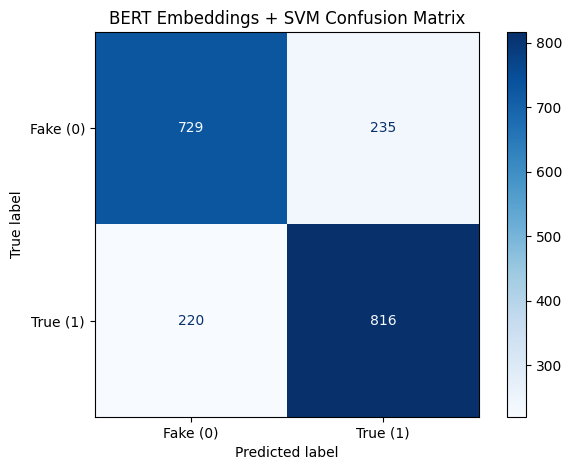

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Fake (0)', 'True (1)'],
    cmap='Blues'
)
plt.title('BERT Embeddings + SVM Confusion Matrix')
plt.tight_layout()
plt.show()